# GOT-OCR 2.0 — бейслайн на рукописных лекциях

**Режимы (`OCR_MODE`):**
- `ocr` — обычный текст
- `format` — текст + LaTeX-формулы _(рекомендуется для лекций)_

## 0. Параметры эксперимента

In [17]:
PDF_PATH   = "lec.pdf"    # путь к PDF
PAGE_NUMS  = [1, 2, 3]    # None → все страницы
OCR_MODE   = "format"     # 'ocr' | 'format'
DPI        = 200          # 200 — быстро, 300 — точнее
RESULTS_DIR = "got_ocr_results"

## 1. Импорты и окружение

In [18]:
import json
import time
from pathlib import Path

import torch
from pdf2image import convert_from_path
from PIL import Image
from IPython.display import display, Markdown, Image as IPImage
from transformers import AutoModelForCausalLM, AutoTokenizer

Path(RESULTS_DIR).mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")
if device == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : NVIDIA GeForce RTX 2080 Ti
VRAM   : 11.3 GB


## 2. Конвертация PDF → изображения

In [19]:
print(f"Конвертация {PDF_PATH} (DPI={DPI}) ...")
all_images = convert_from_path(PDF_PATH, dpi=DPI)
total = len(all_images)
print(f"Всего страниц: {total}")

indices = ([p - 1 for p in PAGE_NUMS if 1 <= p <= total]
           if PAGE_NUMS else list(range(total)))
print(f"Будут обработаны страницы: {[i+1 for i in indices]}")

Конвертация lec.pdf (DPI=200) ...
Всего страниц: 5
Будут обработаны страницы: [1, 2, 3]


### Предпросмотр страниц

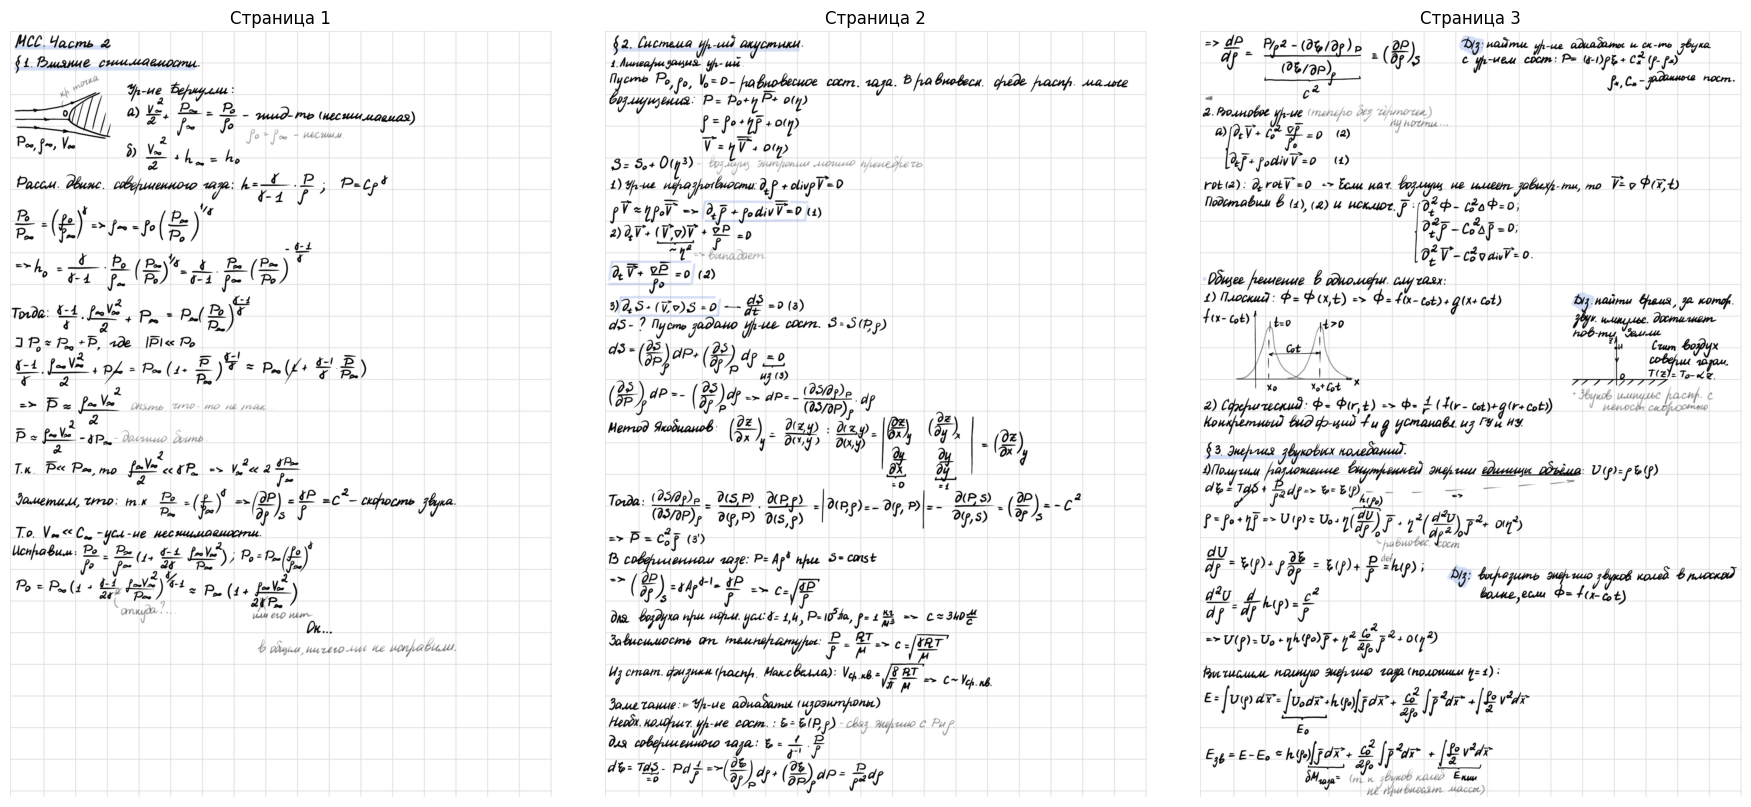

In [4]:
import math
import matplotlib.pyplot as plt

cols = min(3, len(indices))
rows = math.ceil(len(indices) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 8 * rows))
axes = [axes] if len(indices) == 1 else axes.flatten()

for ax, idx in zip(axes, indices):
    ax.imshow(all_images[idx])
    ax.set_title(f"Страница {idx + 1}")
    ax.axis("off")

for ax in axes[len(indices):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Загрузка модели GOT-OCR 2.0

In [5]:
MODEL_ID = "ucaslcl/GOT-OCR2_0"
print(f"Загрузка {MODEL_ID} ...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Загружаем через сам модуль модели, а не через Auto-класс
from transformers import AutoModel
model = AutoModel.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
    device_map=device,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    use_safetensors=True,
    pad_token_id=tokenizer.eos_token_id,
).eval()

print("Модель загружена.")

Загрузка ucaslcl/GOT-OCR2_0 ...


/home/user/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/ucaslcl/GOT-OCR2_0:
- render_tools.py
- got_vision_b.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/home/user/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Модель загружена.


## 4. OCR

In [6]:
TMP_IMG = Path(RESULTS_DIR) / "_tmp.png"
results = {}

for idx in indices:
    page_no = idx + 1
    print(f"\n{'─'*50}")
    print(f"Страница {page_no}")
    print('─'*50)

    # Сохраняем PNG (GOT-OCR принимает путь к файлу)
    all_images[idx].save(str(TMP_IMG))

    t0 = time.time()
    with torch.inference_mode():
        text = model.chat(tokenizer, str(TMP_IMG), ocr_type=OCR_MODE)
    elapsed = time.time() - t0

    results[page_no] = {"mode": OCR_MODE, "elapsed_sec": round(elapsed, 2), "text": text}

    # Сохраняем .md
    md_path = Path(RESULTS_DIR) / f"page_{page_no:03d}.md"
    md_path.write_text(
        f"# Страница {page_no}\n\n_Режим: {OCR_MODE} | Время: {elapsed:.1f}с_\n\n{text}\n",
        encoding="utf-8"
    )

    print(f"Время: {elapsed:.1f}с")
    display(Markdown(f"---\n{text}"))

TMP_IMG.unlink(missing_ok=True)
print(f"\n✓ Готово. Обработано страниц: {len(results)}")


──────────────────────────────────────────────────
Страница 1
──────────────────────────────────────────────────


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Время: 5.1с


---
MCC. Hacmb 2
8. Bismme cummaemum.
o
a)
P
P
P
P
P
P
P
P
P
P
P.
P
P
P
P
P
P
P
P
P
P


──────────────────────────────────────────────────
Страница 2
──────────────────────────────────────────────────


...


──────────────────────────────────────────────────
Страница 3
──────────────────────────────────────────────────


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Время: 10.0с


---
<smiles>[12CH3]O</smiles>
<smiles>[12CH3]O</smiles>
<smiles>[14CH3]O</smiles>
<smiles>[14CH3]O</bram
<smiles>[14CH3]O</smiles>
<smiles>[12CH3]O</bram
<smiles>[14CH3]O</bram
<smiles>[12CH3]O</smiles>
<smiles>[24CH3]O</smiles>
<smiles>[14CH3]O]</smiles>
<smiles>[14CH3]O</smiles>
<smile>[14CH3]O</smiles>
<smiles>[14CH3H]O</smiles>
<smiles>[14CH3]O</smiles>


✓ Готово. Обработано страниц: 3


In [7]:
import subprocess
subprocess.run([
    "pip", "install", "transformers==4.37.2", "-q", "--upgrade"
], check=True)

CompletedProcess(args=['pip', 'install', 'transformers==4.37.2', '-q', '--upgrade'], returncode=0)

## 5. Сохранение результатов

In [10]:
# JSON
json_path = Path(RESULTS_DIR) / "results.json"
json_path.write_text(
    json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8"
)

# Единый Markdown
full_md = Path(RESULTS_DIR) / "full_output.md"
full_md.write_text(
    "\n\n---\n\n".join(
        f"# Страница {p}\n\n{v['text']}" for p, v in results.items()
    ),
    encoding="utf-8"
)

print(f"Сохранено:")
print(f"  {json_path}")
print(f"  {full_md}")
for p in results:
    print(f"  {RESULTS_DIR}/page_{p:03d}.md")

Сохранено:
  got_ocr_results/results.json
  got_ocr_results/full_output.md
  got_ocr_results/page_001.md
  got_ocr_results/page_002.md
  got_ocr_results/page_003.md


## 6. Просмотр результата конкретной страницы

/tmp/ipykernel_10096/2439935660.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


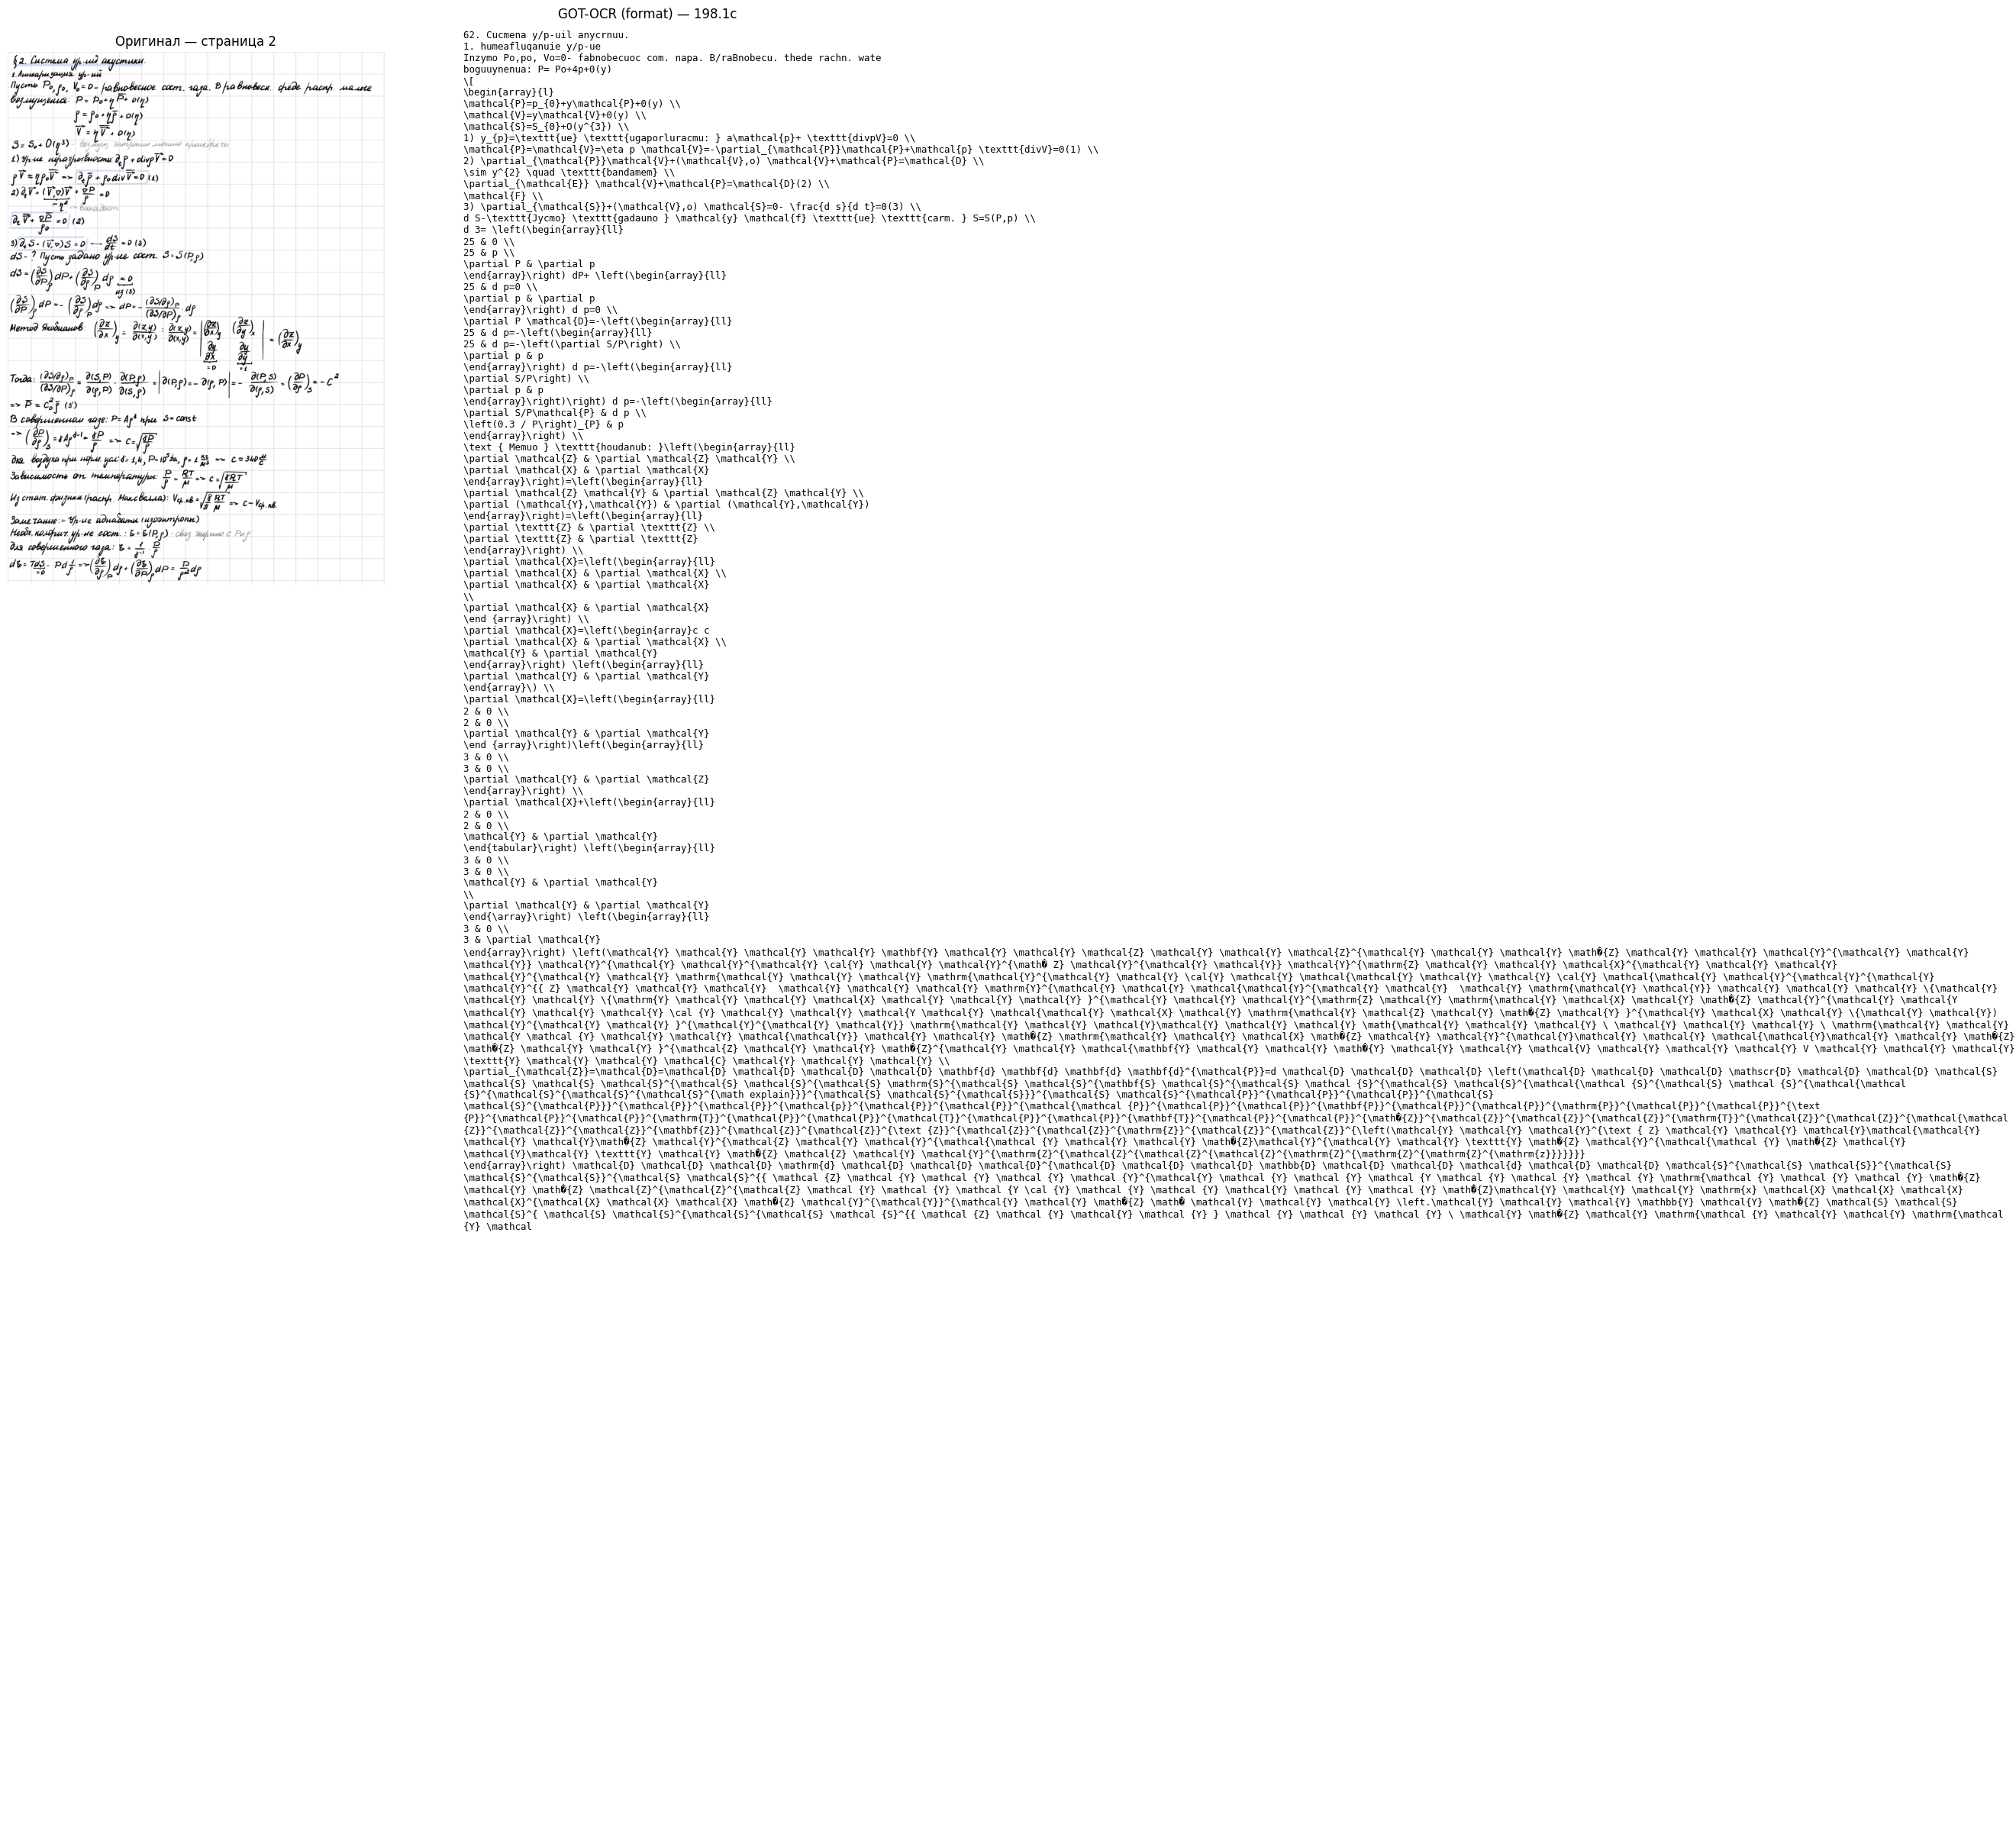

In [11]:
VIEW_PAGE = 2  # ← поменяйте номер страницы

if VIEW_PAGE in results:
    fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(14, 10))

    ax_img.imshow(all_images[VIEW_PAGE - 1])
    ax_img.set_title(f"Оригинал — страница {VIEW_PAGE}")
    ax_img.axis("off")

    ax_txt.axis("off")
    ax_txt.text(
        0.01, 0.99, results[VIEW_PAGE]["text"],
        transform=ax_txt.transAxes,
        va="top", ha="left", fontsize=9,
        wrap=True, family="monospace"
    )
    ax_txt.set_title(f"GOT-OCR ({OCR_MODE}) — {results[VIEW_PAGE]['elapsed_sec']}с")

    plt.tight_layout()
    plt.show()
else:
    print(f"Страница {VIEW_PAGE} не обработана.")

In [6]:
import subprocess
subprocess.run([
    "pip", "install", "opencv-python-headless", "-q", "--force-reinstall"
], check=True)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pix2tex 0.1.4 requires timm==0.5.4, but you have timm 1.0.25 which is incompatible.


CompletedProcess(args=['pip', 'install', 'opencv-python-headless', '-q', '--force-reinstall'], returncode=0)

In [8]:
import surya.model.detection.processor as p
print(dir(p))

['Any', 'BaseImageProcessor', 'BatchFeature', 'ChannelDimension', 'Dict', 'IMAGENET_DEFAULT_MEAN', 'IMAGENET_DEFAULT_STD', 'ImageInput', 'List', 'Optional', 'PIL', 'PILImageResampling', 'SegformerImageProcessor', 'TensorType', 'Union', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'get_size_dict', 'infer_channel_dimension_format', 'make_list_of_images', 'np', 'to_channel_dimension_format', 'torch', 'warnings']


In [11]:
import surya.layout as sl
print(dir(sl))

['Image', 'LayoutBox', 'LayoutResult', 'List', 'Optional', 'ProcessPoolExecutor', 'TextDetectionResult', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'batch_detection', 'batch_layout_detection', 'defaultdict', 'get_and_clean_boxes', 'get_detected_boxes', 'get_regions', 'get_regions_from_detection_result', 'keep_largest_boxes', 'np', 'parallel_get_regions', 'settings']


In [12]:
# -- Настройки -------------------------------------------------
PAGES_TO_CHECK = [1, 2, 3]   # какие страницы смотреть (1-based)

CLASS_STYLE = {
    "Text":           {"color": "#2196F3", "label": "Текст"},
    "Formula":        {"color": "#FF5722", "label": "Формула"},
    "Figure":         {"color": "#4CAF50", "label": "Рисунок"},
    "Table":          {"color": "#9C27B0", "label": "Таблица"},
    "Caption":        {"color": "#FF9800", "label": "Подпись"},
    "Footnote":       {"color": "#795548", "label": "Сноска"},
    "Page-header":    {"color": "#607D8B", "label": "Заголовок"},
    "Page-footer":    {"color": "#9E9E9E", "label": "Колонтитул"},
    "Section-header": {"color": "#00BCD4", "label": "Раздел"},
    "List-item":      {"color": "#8BC34A", "label": "Список"},
    "Picture":        {"color": "#4CAF50", "label": "Картинка"},
    "Equation":       {"color": "#FF5722", "label": "Уравнение"},
}
DEFAULT_COLOR = "#E91E63"

In [24]:
from surya.detection import batch_text_detection
from surya.layout import batch_layout_detection
from surya.model.detection.model import load_model
from surya.model.detection.processor import SegformerImageProcessor

print("Загрузка моделей...")
det_model     = load_model()
det_processor = SegformerImageProcessor.from_pretrained("vikp/surya_det3")
lay_model     = load_model(checkpoint="vikp/surya_layout3")
lay_processor = SegformerImageProcessor.from_pretrained("vikp/surya_layout3")
print("Готово.")

Загрузка моделей...
Loaded detection model vikp/surya_det3 on device cuda with dtype torch.float16
Loaded detection model vikp/surya_layout3 on device cuda with dtype torch.float16
Готово.


In [25]:
indices = [p - 1 for p in PAGES_TO_CHECK if 1 <= p <= len(all_images)]
images  = [all_images[i] for i in indices]

print("Детекция строк...")
line_preds = batch_text_detection(images, det_model, det_processor)

print("Layout detection...")
layout_preds = batch_layout_detection(images, lay_model, lay_processor, line_preds)

print("Готово.")
print("Структура результата:", type(layout_preds[0]))
print("Поля объекта:", dir(layout_preds[0]))

Детекция строк...


Detecting bboxes: 100%|██████████| 1/1 [00:05<00:00,  5.69s/it]


Layout detection...


Detecting bboxes: 100%|██████████| 1/1 [00:15<00:00, 15.04s/it]

Готово.
Структура результата: <class 'surya.schema.LayoutResult'>
Поля объекта: ['__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__class_vars__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__fields_set__', '__format__', '__ge__', '__get_pydantic_core_schema__', '__get_pydantic_json_schema__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__pretty__', '__private_attributes__', '__pydantic_complete__', '__pydantic_computed_fields__', '__pydantic_core_schema__', '__pydantic_custom_init__', '__pydantic_decorators__', '__pydantic_extra__', '__pydantic_fields__', '__pydantic_fields_set__', '__pydantic_generic_metadata__', '__pydantic_init_subclass__', '__pydantic_on_complete__', '__pydantic_parent_namespace__', '__pydantic_post_init__', '__pydantic_private__', '__pydantic_root_mo

In [23]:
from surya.settings import settings
print("det checkpoint: ", settings.DETECTOR_MODEL_CHECKPOINT)
print("layout checkpoint:", settings.LAYOUT_MODEL_CHECKPOINT)


det checkpoint:  vikp/surya_det3
layout checkpoint: vikp/surya_layout3


In [26]:
# Смотрим структуру одного bbox
sample = layout_preds[0]
print("image_bbox:", sample.image_bbox)
print("bboxes count:", len(sample.bboxes))
if sample.bboxes:
    b = sample.bboxes[0]
    print("bbox fields:", dir(b))
    print("bbox[0]:", b)

image_bbox: [0.0, 0.0, 4445.0, 6287.0]
bboxes count: 1
bbox fields: ['__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__class_vars__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__fields_set__', '__format__', '__ge__', '__get_pydantic_core_schema__', '__get_pydantic_json_schema__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__pretty__', '__private_attributes__', '__pydantic_complete__', '__pydantic_computed_fields__', '__pydantic_core_schema__', '__pydantic_custom_init__', '__pydantic_decorators__', '__pydantic_extra__', '__pydantic_fields__', '__pydantic_fields_set__', '__pydantic_generic_metadata__', '__pydantic_init_subclass__', '__pydantic_on_complete__', '__pydantic_parent_namespace__', '__pydantic_post_init__', '__pydantic_private__', '__pydantic_root_model__', '__p